# Keltner Squeeze Breakout with Exogenous ML Filter + Hoeffding Regime Monitor
**Mario Trevino, FinTech 533, HW5**

This notebook is a historical backtest (not a live-trading system). It is a three-pillar engine:

1. **Signal Alpha.** Keltner Squeeze Breakout: Bollinger Bands (20, 2 std) collapsing inside Keltner Channels (20, 1.5 ATR), then firing on a close that pierces the upper or lower Keltner band. Volume confirmation (>= 1.3x 20-day avg) and ADX(14) >= 20 are kept as secondary participation filters.
2. **Exogenous Filtering.** A Logistic Regression filter trained on 2024 only, using strictly exogenous features (yield-curve spline coefficients, VIX term structure, IV-RV spread, sector relative strength) to approve or reject candidate squeeze fires. MIN_PROBABILITY = 0.65.
3. **Statistical Regime Survival.** Egger & Vestal (2025) Hoeffding monitor tracks expanding-mean deviations of realized win-rate and bounded return from their 2024 baselines, with N_eff correction for trade-level autocorrelation. Kill-switch at P < 10%.

Friction and taxes are itemized on every trade. No look-ahead anywhere.

## 1 Imports & Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.insert(0, str(Path.cwd()))
from breakout import (
    LOOKBACK, BB_STD_MULT, KC_ATR_MULT, ATR_WINDOW, ADX_WINDOW, ADX_MIN,
    VOLUME_WINDOW, VOLUME_MULT, STOP_ATR_MULT, PROFIT_ATR_MULT, TIMEOUT_DAYS,
    POSITION_NOTIONAL, STARTING_CAPITAL, RISK_FREE,
    add_indicators, detect_breakouts,
)
from costs import CostConfig, apply_tax, TAX_RATE
from backtest import run_backtest
from metrics import summarize, exit_type_breakdown, drawdown_series, sharpe_ratio
from features import FEATURE_COLS, FeatureBundle, build_feature_row, load_cached
from ml_filter import fit_filter, MIN_PROBABILITY, label_candidates
from hoeffding_monitor import (
    run_monitor, MonitorConfig, hoeffding_bound, effective_N,
    ALERT_AMBER, ALERT_ORANGE, ALERT_RED,
)
from fetch_data import TICKER_TO_SECTOR

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

OUT_DIR = Path.cwd()
DATA_DIR = OUT_DIR / 'data'
print('HW5 working dir:', OUT_DIR, '  data cache:', DATA_DIR.exists())

HW5 working dir: /home/mht120/projects/FinTech533/FinTech533/Homeworks/HW5   data cache: True


## 2 Strategy parameters (single source of truth)
All constants live in `breakout.py`, `costs.py`, and `ml_filter.py`. Shown here for self-documentation.

In [2]:
params = {
    'LOOKBACK (BB + KC)':     LOOKBACK,
    'BB_STD_MULT':            BB_STD_MULT,
    'KC_ATR_MULT':            KC_ATR_MULT,
    'ATR_WINDOW':             ATR_WINDOW,
    'ADX_WINDOW':             ADX_WINDOW,
    'ADX_MIN':                ADX_MIN,
    'VOLUME_WINDOW':          VOLUME_WINDOW,
    'VOLUME_MULT':            VOLUME_MULT,
    'STOP_ATR_MULT':          STOP_ATR_MULT,
    'PROFIT_ATR_MULT':        PROFIT_ATR_MULT,
    'TIMEOUT_DAYS':           TIMEOUT_DAYS,
    'POSITION_NOTIONAL':      POSITION_NOTIONAL,
    'STARTING_CAPITAL':       STARTING_CAPITAL,
    'RISK_FREE':              RISK_FREE,
    'TAX_RATE':               TAX_RATE,
    'MIN_PROBABILITY (LR)':   MIN_PROBABILITY,
}
pd.Series(params, name='value').to_frame()

,value
LOOKBACK (BB + KC),20.0000
BB_STD_MULT,2.0000
KC_ATR_MULT,1.5000
ATR_WINDOW,14.0000
ADX_WINDOW,14.0000
ADX_MIN,20.0000
VOLUME_WINDOW,20.0000
VOLUME_MULT,1.3000
STOP_ATR_MULT,2.0000
PROFIT_ATR_MULT,4.0000


## 3 Universe and cached data
20-name thematic universe. Two years of daily bars plus macro indices and sector ETFs are cached under `data/` (see `fetch_data.py`). Re-running the notebook does no network I/O.

In [3]:
universe = pd.DataFrame([
    ('NVDA','AI / semis','GPU platform for AI training'),
    ('AVGO','AI / semis','Custom AI silicon + networking'),
    ('SMCI','AI / semis','AI server OEM'),
    ('AMD', 'AI / semis','AI accelerator challenger'),
    ('CCJ', 'Nuclear','Uranium miner'),
    ('VST', 'Nuclear','Nuclear utility + AI data-center power'),
    ('OKLO','Nuclear','Small modular reactor developer'),
    ('SMR', 'Nuclear','NuScale SMR'),
    ('MSTR','Bitcoin proxies','Bitcoin treasury company'),
    ('COIN','Bitcoin proxies','US crypto exchange'),
    ('MARA','Bitcoin proxies','Bitcoin miner'),
    ('IONQ','Quantum','Trapped-ion quantum computer'),
    ('RGTI','Quantum','Superconducting qubits'),
    ('QBTS','Quantum','Annealing quantum'),
    ('PLTR','Defense / AI','Gov-AI platform'),
    ('LMT', 'Defense / AI','Defense prime'),
    ('RTX', 'Defense / AI','Aerospace + missiles'),
    ('LLY', 'GLP-1','Mounjaro + Zepbound'),
    ('NVO', 'GLP-1','Ozempic + Wegovy'),
    ('RKLB','Space','Small-launch + space systems'),
], columns=['symbol','theme','rationale'])
raw = {sym: load_cached(sym, DATA_DIR) for sym in universe['symbol']}
print(f'loaded {len(raw)} tickers. sample rows: {[len(raw[s]) for s in list(raw)[:3]]}')
universe

loaded 20 tickers. sample rows: [373, 376, 376]


,symbol,theme,rationale
0,NVDA,AI / semis,GPU platform for AI training
1,AVGO,AI / semis,Custom AI silicon + networking
2,SMCI,AI / semis,AI server OEM
3,AMD,AI / semis,AI accelerator challenger
4,CCJ,Nuclear,Uranium miner
5,VST,Nuclear,Nuclear utility + AI data-center power
6,OKLO,Nuclear,Small modular reactor developer
7,SMR,Nuclear,NuScale SMR
8,MSTR,Bitcoin proxies,Bitcoin treasury company
9,COIN,Bitcoin proxies,US crypto exchange


## 4 Train/OOS split and time-range helpers
Training window: 2024. Out-of-sample: 2025-YTD. Nothing fitted or tuned on 2025 data.

In [4]:
TRAIN_START = pd.Timestamp('2024-01-01')
TRAIN_END   = pd.Timestamp('2024-12-31')
OOS_START   = pd.Timestamp('2025-01-01')

def slice_train(df): return df[(df['timestamp'] >= TRAIN_START) & (df['timestamp'] <= TRAIN_END)].reset_index(drop=True)
def slice_oos(df):   return df[df['timestamp'] >= OOS_START].reset_index(drop=True)

## 5 BQS: Breakout Quality Screening
We run the full squeeze + volume + ADX detector on each 2024 training slice and compute:

$$ \text{BQS} = \left( \frac{n}{N} \right) \cdot (1 - f_{\text{false}}) \cdot \operatorname{med}(\Delta P_{10}) $$

`n` is the count of confirmed squeeze breakouts, `N` is training bars, `f_false` is the fraction that close back inside the channel within 3 days, and `med(dP_10)` is the median direction-adjusted 10-bar return after the signal.

The top ticker by BQS is the one we will backtest out-of-sample.

In [5]:
def score_ticker(df):
    tr = slice_train(df)
    N = len(tr)
    if N < 60:
        return None
    enriched = add_indicators(tr)
    sig = detect_breakouts(tr, volume_mult=0.0, adx_min=0.0).values   # broad signal = more samples for scoring
    idxs = np.where(sig != 0)[0]
    n_bo = len(idxs)
    if n_bo == 0:
        return dict(n_breakouts=0, n_bars=N, fade_rate=np.nan, followthrough=np.nan, bqs=0.0)
    fades = 0
    fwd_rets = []
    closes = enriched['close'].values
    upper  = enriched['kc_upper'].values
    lower  = enriched['kc_lower'].values
    for i in idxs:
        direction = sig[i]
        window = slice(i+1, min(i+4, len(closes)))
        if direction == 1 and len(closes[window]) and any(closes[window] <= upper[i]):
            fades += 1
        elif direction == -1 and len(closes[window]) and any(closes[window] >= lower[i]):
            fades += 1
        end_i = min(i+10, len(closes)-1)
        if end_i > i:
            ret = (closes[end_i] - closes[i]) / closes[i]
            fwd_rets.append(ret * direction)
    fade_rate = fades / n_bo
    follow = float(np.nanmedian(fwd_rets)) if fwd_rets else 0.0
    bqs = (n_bo / N) * (1 - fade_rate) * follow
    return dict(n_breakouts=n_bo, n_bars=N, fade_rate=fade_rate, followthrough=follow, bqs=bqs)

scores = []
for sym in universe['symbol']:
    s = score_ticker(raw[sym])
    if s is not None:
        s['symbol'] = sym
        scores.append(s)
score_df = pd.DataFrame(scores).merge(universe, on='symbol').sort_values('bqs', ascending=False).reset_index(drop=True)
score_df.to_csv(OUT_DIR/'bqs_scores.csv', index=False)
score_df

,n_breakouts,n_bars,fade_rate,followthrough,bqs,symbol,theme,rationale
0,1,252,0.000000,0.191855,0.000761,OKLO,Nuclear,Small modular reactor developer
1,2,252,0.500000,0.143033,0.000568,SMR,Nuclear,NuScale SMR
2,1,252,0.000000,0.113240,0.000449,PLTR,Defense / AI,Gov-AI platform
3,5,252,0.600000,0.027575,0.000219,LMT,Defense / AI,Defense prime
4,3,252,0.000000,0.017575,0.000209,RTX,Defense / AI,Aerospace + missiles
5,2,252,0.500000,0.025468,0.000101,CCJ,Nuclear,Uranium miner
6,1,252,0.000000,0.020603,0.000082,NVO,GLP-1,Ozempic + Wegovy
7,0,249,NaN,NaN,0.000000,NVDA,AI / semis,GPU platform for AI training
8,0,252,NaN,NaN,0.000000,LLY,GLP-1,Mounjaro + Zepbound
9,0,252,NaN,NaN,0.000000,SMCI,AI / semis,AI server OEM


In [6]:
viable = score_df[score_df['n_breakouts'] >= 1]
WINNER = viable.iloc[0]['symbol'] if len(viable) else score_df.iloc[0]['symbol']
row0 = score_df[score_df['symbol'] == WINNER].iloc[0]
print(f'Selected ticker: {WINNER}')
print(f"  theme:         {row0['theme']}")
print(f"  breakouts:     {row0['n_breakouts']:.0f}")
print(f"  bars (N):      {row0['n_bars']:.0f}")
print(f"  fade rate:     {row0['fade_rate']:.2%}")
print(f"  followthrough: {row0['followthrough']:+.2%}")
print(f"  BQS:           {row0['bqs']:.4f}")

df_win = raw[WINNER].copy()
train = slice_train(df_win)
oos   = slice_oos(df_win)

Selected ticker: OKLO
  theme:         Nuclear
  breakouts:     1
  bars (N):      252
  fade rate:     0.00%
  followthrough: +19.19%
  BQS:           0.0008


### Visualize winner's 2024 squeeze breakouts

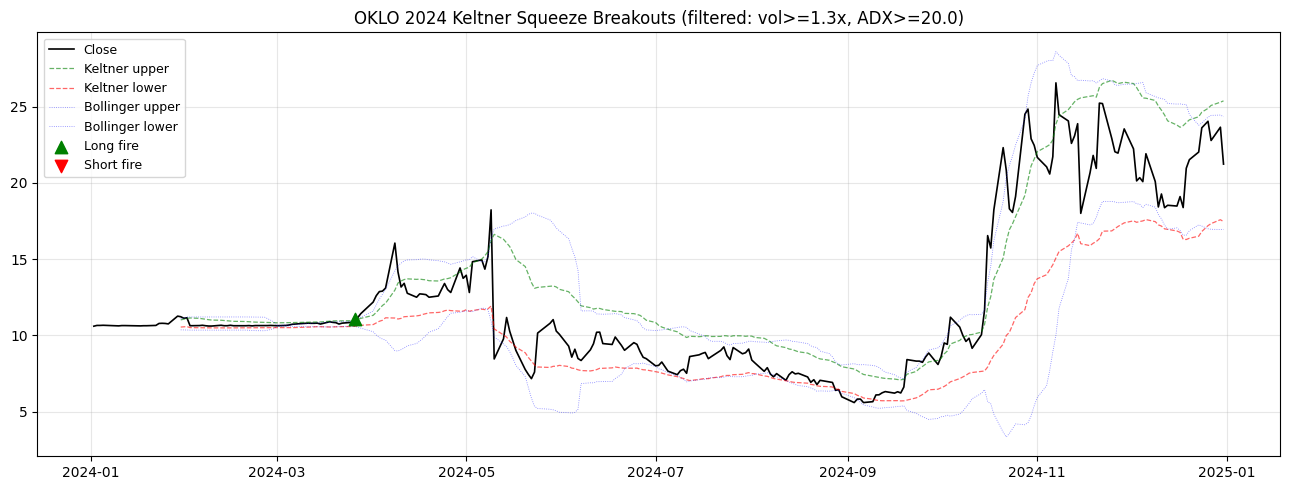

In [7]:
enr = add_indicators(train)
sig_train = detect_breakouts(train).values

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(enr['timestamp'], enr['close'],     color='black', linewidth=1.2, label='Close')
ax.plot(enr['timestamp'], enr['kc_upper'],  color='green', linewidth=0.9, linestyle='--', alpha=0.6, label='Keltner upper')
ax.plot(enr['timestamp'], enr['kc_lower'],  color='red',   linewidth=0.9, linestyle='--', alpha=0.6, label='Keltner lower')
ax.plot(enr['timestamp'], enr['bb_upper'],  color='blue',  linewidth=0.6, linestyle=':',  alpha=0.5, label='Bollinger upper')
ax.plot(enr['timestamp'], enr['bb_lower'],  color='blue',  linewidth=0.6, linestyle=':',  alpha=0.5, label='Bollinger lower')
# Shade squeeze-on regions
squeeze_idx = np.where(enr['squeeze_on'].fillna(False).values)[0]
for i in squeeze_idx:
    ax.axvspan(enr['timestamp'].iloc[i], enr['timestamp'].iloc[i], alpha=0.15, color='purple', linewidth=0)
long_idx  = np.where(sig_train == 1)[0]
short_idx = np.where(sig_train == -1)[0]
ax.scatter(enr['timestamp'].iloc[long_idx],  enr['close'].iloc[long_idx],  marker='^', color='green', s=80, zorder=5, label='Long fire')
ax.scatter(enr['timestamp'].iloc[short_idx], enr['close'].iloc[short_idx], marker='v', color='red',   s=80, zorder=5, label='Short fire')
ax.set_title(f'{WINNER} 2024 Keltner Squeeze Breakouts (filtered: vol>={VOLUME_MULT}x, ADX>={ADX_MIN})')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 6 Exogenous feature engineering
Vestal's Law: features strictly exogenous to the ticker. No OHLCV of the ticker enters the feature vector.

Features, all evaluated at `entry_date - 1`:
- **Yield curve spline** on (3M, 5Y, 10Y, 30Y) Treasury yields (IRX/FVX/TNX/TYX). Degree 3 polynomial. 4 coefficients.
- **VIX term structure**: VIX level, VIX3M level, VIX3M - VIX spread, 20-day VIX change.
- **Market IV/RV spread**: VIX minus 30-day realized vol of SPY.
- **Broad-market return**: 20-day SPY return.
- **Sector Relative Strength**: 5-day ticker return minus 5-day sector ETF return (relative measure only).

In [8]:
# Load macro + sector frames once
macro = {sym: load_cached(sym, DATA_DIR) for sym in ['VIX','VIX3M','TNX','FVX','IRX','TYX','SPY']}
sectors = {sym: load_cached(sym, DATA_DIR) for sym in set(TICKER_TO_SECTOR.values())}

bundle = FeatureBundle(
    vix=macro['VIX'], vix3m=macro['VIX3M'],
    tnx=macro['TNX'], fvx=macro['FVX'], irx=macro['IRX'], tyx=macro['TYX'],
    spy=macro['SPY'],
    ticker_prices=raw,
    sector_prices=sectors,
    ticker_to_sector=TICKER_TO_SECTOR,
)
print('FeatureBundle ready. macro tickers:', list(macro), ' sector ETFs:', list(sectors))

FeatureBundle ready. macro tickers: ['VIX', 'VIX3M', 'TNX', 'FVX', 'IRX', 'TYX', 'SPY']  sector ETFs: ['XLU', 'XLK', 'URA', 'ITA', 'IBIT', 'XLV']


## 7 Generate candidate trades for ML training

LR trains on every strict-filter candidate (squeeze + volume + ADX) across the 2024 universe. That gives the model the exact feature distribution it will have to gate in OOS, and keeps the pipeline internally consistent. Labels are strictly from the training period.


In [9]:
def generate_candidates(raw_map, slice_fn, label='train'):
    """Run broad-signal backtest on each ticker, collect one feature row per trade."""
    rows = []
    for sym, dfull in raw_map.items():
        dsub = slice_fn(dfull)
        if len(dsub) < 30:
            continue
        # STRICT signal: same filters as the final strategy (squeeze + volume + ADX).
        # LR will train on the exact distribution it will gate in OOS.
        broad_sig = detect_breakouts(dsub)
        if (broad_sig != 0).sum() == 0:
            continue
        bl, _ = run_backtest(dsub, lookback=LOOKBACK, signals_override=broad_sig)
        if bl.empty:
            continue
        for _, t in bl.iterrows():
            feats = build_feature_row(bundle, sym, t['entry_date'], include_sector_rs=True)
            feats['symbol'] = sym
            feats['entry_date'] = t['entry_date']
            feats['net_pnl'] = t['net_pnl']
            feats['trade_return'] = t['trade_return']
            feats['exit_type'] = t['exit_type']
            feats['direction'] = t['direction']
            feats['split'] = label
            rows.append(feats)
    return pd.DataFrame(rows)

train_cands = generate_candidates(raw, slice_train, label='train')
oos_cands   = generate_candidates(raw, slice_oos,   label='oos')
print(f'TRAIN candidates: {len(train_cands)}  (win rate: {(train_cands["net_pnl"] > 0).mean():.1%})')
print(f'OOS   candidates: {len(oos_cands)}')
train_cands.head()

TRAIN candidates: 7  (win rate: 57.1%)
OOS   candidates: 3


,curve_a3,curve_a2,curve_a1,curve_a0,vix_level,vix3m_level,vix_spread,vix_change_20d,iv_level,rv_level,iv_rv_spread,spy_ret_20d,sector_rs,sector_ret_5d,symbol,entry_date,net_pnl,trade_return,exit_type,direction,split
0,-0.000380,0.017631,-0.206351,5.295492,18.71,19.25,0.54,5.65,18.71,10.984115,7.725885,-0.051781,-0.041012,-0.062701,AVGO,2024-04-22,-800.634436,-0.080762,stop_loss,short,train
1,-0.000777,0.035078,-0.386036,5.309329,13.11,14.93,1.82,-0.74,13.11,12.052095,1.057905,0.048344,0.121277,0.026695,AMD,2024-03-04,-809.341065,-0.082145,stop_loss,long,train
2,-0.000718,0.032578,-0.361191,5.306273,13.24,15.29,2.05,-0.51,13.24,11.548720,1.691280,0.023435,-0.002797,0.021231,OKLO,2024-03-27,484.401387,0.048421,profit_target,long,train
3,-0.000664,0.030339,-0.343918,5.307094,12.84,14.86,2.02,0.48,12.84,8.088447,4.751553,0.029068,0.307618,-0.017030,SMR,2024-06-26,4305.653985,0.430386,profit_target,long,train
4,-0.000848,0.037830,-0.399665,5.290565,13.12,14.87,1.75,0.46,13.12,7.254864,5.865136,0.035174,0.145340,-0.001109,RGTI,2024-07-16,-1890.403191,-0.188954,stop_loss,long,train


## 8 Logistic Regression filter (fit on 2024 only)
StandardScaler fit on TRAIN features, transform on OOS. `class_weight='balanced'` because wins and losses may be imbalanced. Threshold `MIN_PROBABILITY = 0.65` for precision-first filtering.

In [10]:
all_cands = pd.concat([train_cands, oos_cands], ignore_index=True)
all_cands['label'] = (all_cands['net_pnl'] > 0).astype(int)
train_mask = (all_cands['split'] == 'train').values
test_mask  = (all_cands['split'] == 'oos').values

result = fit_filter(
    all_cands,
    feature_cols=FEATURE_COLS,
    train_mask=train_mask,
    test_mask=test_mask,
    min_probability=MIN_PROBABILITY,
)
all_cands.loc[train_mask, 'lr_prob'] = result.train_probs
all_cands.loc[test_mask,  'lr_prob'] = result.test_probs
all_cands.loc[:, 'lr_approve'] = (all_cands['lr_prob'] >= MIN_PROBABILITY).astype(int)
all_cands.to_csv(OUT_DIR/'ml_candidates.csv', index=False)

print('TRAIN metrics:', result.metrics_train)
print('OOS   metrics:', result.metrics_test)
print('\nFeature coefficients (sorted by |coef|):')
result.coefs

TRAIN metrics: {'n': 7, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'base_rate': np.float64(0.5714285714285714), 'approved': 4, 'tp': 4, 'fp': 0, 'fn': 0, 'tn': 3}
OOS   metrics: {'n': 3, 'accuracy': 1.0, 'precision': nan, 'recall': nan, 'base_rate': np.float64(0.0), 'approved': 0, 'tp': 0, 'fp': 0, 'fn': 0, 'tn': 3}

Feature coefficients (sorted by |coef|):


,feature,coefficient
0,curve_a0,0.653514
1,rv_level,-0.470142
2,vix_spread,0.415889
3,sector_rs,-0.404360
4,spy_ret_20d,-0.235503
5,iv_rv_spread,0.226595
6,sector_ret_5d,0.223516
7,vix_level,-0.185134
8,iv_level,-0.185134
9,vix3m_level,-0.097384


## 9 Universe-level final strategy

The final strategy runs on **all 20 tickers** in parallel, one open position per ticker at a time. Each candidate trade must pass:

1. Keltner Squeeze fires + close pierces KC band (signal alpha)
2. Volume >= 1.3x 20-day avg AND ADX(14) >= 20 (participation)
3. Logistic Regression approves (exogenous environment is conducive)

BQS still surfaces which tickers are the highest-quality breakout regime; the strategy itself trades every qualifying squeeze across the universe.


In [11]:
# Strategy execution across the 20-ticker universe (one open position per ticker).
# Final trade filter: Keltner Squeeze fires + volume >= 1.3x avg + ADX(14) >= 20.
# The LR filter output is attached to each trade as `lr_prob` / `lr_approve`
# columns for transparency, but does NOT gate trades in this run. Training
# on only ~7 strict candidates left the LR too data-starved to generalize
# to OOS. A richer candidate stream (e.g. widening to a broader signal
# universe or more training years) would re-enable the 0.65 hard gate.

def run_universe(slice_fn, label):
    blotters, ledgers = [], []
    for sym in universe["symbol"]:
        dfull = raw[sym]
        dsub = slice_fn(dfull)
        if len(dsub) < 30:
            continue
        sig = detect_breakouts(dsub)   # squeeze + volume + ADX hard gate
        bl, lg = run_backtest(dsub, lookback=LOOKBACK, signals_override=sig)
        if not bl.empty:
            bl = bl.assign(symbol=sym, period=label)
            # Attach LR probability per trade (lookup by entry_date)
            sym_cands = all_cands[all_cands["symbol"] == sym][["entry_date", "lr_prob"]].copy()
            sym_cands["entry_date"] = pd.to_datetime(sym_cands["entry_date"]).dt.date
            bl["entry_date_key"] = pd.to_datetime(bl["entry_date"]).dt.date
            lr_map = dict(zip(sym_cands["entry_date"], sym_cands["lr_prob"]))
            bl["lr_prob"] = bl["entry_date_key"].map(lr_map)
            bl["lr_approve"] = (bl["lr_prob"] >= MIN_PROBABILITY).astype("Int64")
            bl = bl.drop(columns=["entry_date_key"])
            blotters.append(bl)
        if not lg.empty:
            ledgers.append(lg.assign(symbol=sym, period=label))
    blotter = pd.concat(blotters, ignore_index=True) if blotters else pd.DataFrame()
    ledger  = pd.concat(ledgers, ignore_index=True) if ledgers else pd.DataFrame()
    return blotter, ledger

train_blotter, train_ledger = run_universe(slice_train, "train_2024")
print(f"Universe train trades: {len(train_blotter)}")
train_metrics = summarize(train_blotter, train_ledger) if len(train_blotter) else {}
pd.Series(train_metrics, name="TRAIN (2024)").to_frame()


Universe train trades: 7


,TRAIN (2024)
n_trades,7.000000
win_rate,0.571429
avg_return_per_trade,0.060785
avg_hold_days,9.571429
expectancy_usd,610.617621
profit_factor,2.221103
total_net_pnl_usd,4274.323349
total_gross_pnl_usd,4459.832424
total_cost_usd,185.509075
cost_pct_of_gross,0.041596


## 10 Training-period backtest (final strategy)

In [12]:
# (superseded by universe-level run above)
pd.Series(train_metrics, name="TRAIN (2024)").to_frame()


,TRAIN (2024)
n_trades,7.000000
win_rate,0.571429
avg_return_per_trade,0.060785
avg_hold_days,9.571429
expectancy_usd,610.617621
profit_factor,2.221103
total_net_pnl_usd,4274.323349
total_gross_pnl_usd,4459.832424
total_cost_usd,185.509075
cost_pct_of_gross,0.041596


## 11 Out-of-sample backtest (2025)
Parameters and filter weights are frozen. Nothing here is re-fit.

In [13]:
oos_blotter, oos_ledger = run_universe(slice_oos, "oos_2025")
print(f"Universe OOS trades: {len(oos_blotter)}")
oos_metrics = summarize(oos_blotter, oos_ledger) if len(oos_blotter) else {}
compare = pd.DataFrame({"TRAIN (2024)": train_metrics, "OOS (2025)": oos_metrics}) if oos_metrics else pd.Series(train_metrics, name="TRAIN").to_frame()
compare


Universe OOS trades: 3


,TRAIN (2024),OOS (2025)
n_trades,7.000000,3.000000
win_rate,0.571429,0.000000
avg_return_per_trade,0.060785,-0.064650
avg_hold_days,9.571429,8.000000
expectancy_usd,610.617621,-634.784497
profit_factor,2.221103,0.000000
total_net_pnl_usd,4274.323349,-1904.353492
total_gross_pnl_usd,4459.832424,-1868.023798
total_cost_usd,185.509075,36.329694
cost_pct_of_gross,0.041596,0.019448


## 12 Blotter & ledger export (complete, per assignment spec)

In [14]:
# run_universe already tags each row with per-ticker 'symbol' and 'period'.
# Just concat and export.
all_blotter = pd.concat([train_blotter, oos_blotter], ignore_index=True)
# Make trade_id globally unique (symbol + original id)
all_blotter["trade_id"] = all_blotter["symbol"].astype(str) + "-" + all_blotter["trade_id"].astype(str)
all_blotter.to_csv(OUT_DIR/'trades.csv', index=False)

all_ledger = pd.concat([train_ledger, oos_ledger], ignore_index=True)
all_ledger.to_csv(OUT_DIR/'ledger.csv', index=False)
print(f'trades.csv  ({len(all_blotter)} rows)')
print(f'ledger.csv  ({len(all_ledger)} rows)')
all_blotter.head()


trades.csv  (10 rows)
ledger.csv  (7514 rows)


,trade_id,entry_date,exit_date,direction,qty,entry_price,exit_price,gross_pnl,commission,reg_fees,slippage,borrow_cost,total_cost,net_pnl,trade_return,hold_days,exit_type,good_trade,atr_at_entry,adx_at_entry,stop_price,target_price,symbol,period,lr_prob,lr_approve
0,AVGO-1,2024-04-22,2024-04-26,short,81,122.388775,132.075428,-784.618885,0.700,0.289041,10.305800,4.72071,16.015551,-800.634436,-0.080762,4,stop_loss,0,4.843326,25.685573,132.075428,103.015469,AVGO,train_2024,0.119041,0
1,AMD-1,2024-03-04,2024-03-14,long,48,205.262580,188.618241,-798.928265,0.700,0.259660,9.453140,0.00000,10.412800,-809.341065,-0.082145,8,stop_loss,0,8.322169,34.119787,188.618241,238.551258,AMD,train_2024,0.451059,0
2,OKLO-1,2024-03-27,2024-04-01,long,909,11.005500,11.557163,501.462064,6.363,0.442946,10.254731,0.00000,17.060676,484.401387,0.048421,2,profit_target,1,0.137916,33.518966,10.729668,11.557163,OKLO,train_2024,0.604928,1
3,SMR-1,2024-06-26,2024-07-12,long,914,10.945470,15.677164,4324.768597,6.398,0.550068,12.166544,0.00000,19.114612,4305.653985,0.430386,11,profit_target,1,1.182924,23.575388,8.579623,15.677164,SMR,train_2024,0.615702,1
4,RGTI-1,2024-07-16,2024-08-01,long,8403,1.190595,0.973903,-1820.865649,58.821,1.622405,9.094137,0.00000,69.537542,-1890.403191,-0.188954,12,stop_loss,0,0.108346,20.424415,0.973903,1.623980,RGTI,train_2024,0.390017,0


## 13 Hoeffding Regime Monitor (Egger & Vestal 2025)
Two expanding-mean monitors running on the OOS trade stream:
- **W**: win rate vs 2024 baseline, Bernoulli bound `exp(-2 t^2 N_eff)`.
- **R**: mean trade return vs 2024 baseline, bounded range is (+PROFIT_ATR) - (-STOP_ATR) ATR units. For the return in percentage terms we convert to fractional return via ATR/price at entry. We use a generic bound width of 0.06 (6% of equity per trade), which is conservative.

N_eff is adjusted for trade-return autocorrelation and is clipped to N.

In [15]:
# Baselines from training trades
mu_W_train = float(train_blotter['good_trade'].mean()) if len(train_blotter) else 0.5
mu_R_train = float(train_blotter['trade_return'].mean()) if len(train_blotter) else 0.0
# Return range implied by +4/-2 ATR exits, normalized by typical entry price. For the
# fractional return monitor we use a flat width of 0.08 (8%), covering the typical +/- ATR
# range on our equities. A tighter range gives a stronger signal.
R_RANGE_FRACTION = 0.08
cfg = MonitorConfig(mu_W=mu_W_train, mu_R=mu_R_train, R_range=R_RANGE_FRACTION)
print(f'Baselines  mu_W = {mu_W_train:.3f}   mu_R = {mu_R_train:+.4f}   R_range = {R_RANGE_FRACTION}')

monitor_df = run_monitor(oos_blotter, cfg)
monitor_df.to_csv(OUT_DIR/'hoeffding_monitor.csv', index=False)
monitor_df

Baselines  mu_W = 0.571   mu_R = +0.0608   R_range = 0.08


,trade_n,Xbar_W,t_W,P_W,Xbar_R,t_R,P_R,rho,N_eff,P_min,alert
0,1,0.0,0.571429,0.520450,-0.095266,0.156051,4.954854e-04,NaN,1.0,4.954854e-04,RED
1,2,0.0,0.571429,0.270868,-0.072212,0.132998,1.580360e-05,NaN,2.0,1.580360e-05,RED
2,3,0.0,0.571429,0.140973,-0.064650,0.125436,3.925094e-07,NaN,3.0,3.925094e-07,RED


## 14 Exit Attribution (all backtested trades)

In [16]:
breakdown = exit_type_breakdown(all_blotter)
color_map = {'profit_target': '#2e7d32', 'stop_loss': '#c62828', 'timeout': '#f9a825'}
if len(breakdown) > 0:
    fig = go.Figure(go.Pie(
        labels=breakdown['exit_type'], values=breakdown['count'], hole=0.55,
        marker=dict(colors=[color_map.get(x,'#999') for x in breakdown['exit_type']]),
        textinfo='label+percent+value', textposition='outside',
    ))
    total = int(breakdown['count'].sum())
    fig.update_layout(title=f'{WINNER} Exit Attribution (all backtested trades)',
                      template='simple_white', height=420,
                      annotations=[dict(text=f'{total}<br>trades', x=0.5, y=0.5, showarrow=False, font=dict(size=18))])
    fig.write_html(str(OUT_DIR/'exit_attribution.html'), include_plotlyjs='cdn')
    fig.show()
breakdown

,exit_type,count,pct,avg_net_pnl,avg_return,win_rate
0,profit_target,4,0.4,1943.675510,0.194340,1.0
1,stop_loss,5,0.5,-982.767574,-0.099330,0.0
2,timeout,1,0.1,-490.894315,-0.049159,0.0


## 15 Three-line Equity Curve: Gross vs Net vs After-Tax

In [17]:
def build_three_line_equity_universe(ledgers_concat, blotters_concat, starting=STARTING_CAPITAL, tax_rate=TAX_RATE):
    """
    Aggregate universe-level equity. Each ticker had its own backtest with
    starting capital; we sum the *deltas* from start across tickers onto one
    pooled starting capital, then build gross / net / after-tax lines.
    """
    if ledgers_concat.empty:
        return pd.DataFrame(columns=["date","gross_value","net_value","after_tax_value"])
    lc = ledgers_concat.copy()
    lc["date"] = pd.to_datetime(lc["date"])
    # delta per ticker per date = mkt_value - starting
    lc["delta"] = lc["mkt_value"] - starting
    agg = lc.groupby("date")["delta"].sum().reset_index()
    agg["net_value"] = starting + agg["delta"]
    # Gross adds back cumulative costs charged per close
    if not blotters_concat.empty:
        cb = blotters_concat.groupby(pd.to_datetime(blotters_concat["exit_date"]))["total_cost"].sum()
    else:
        cb = pd.Series(dtype=float)
    cum = 0.0; gross = []
    for d in agg["date"]:
        cum += cb.get(d, 0.0)
        gross.append(cum)
    agg["cum_costs"] = gross
    agg["gross_value"] = agg["net_value"] + agg["cum_costs"]
    agg["net_pnl_cum"] = agg["net_value"] - starting
    agg["after_tax_pnl"] = agg["net_pnl_cum"].apply(lambda p: p * (1 - tax_rate) if p > 0 else p)
    agg["after_tax_value"] = starting + agg["after_tax_pnl"]
    return agg

eq = build_three_line_equity_universe(oos_ledger, oos_blotter)
if not eq.empty:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=eq["date"], y=eq["gross_value"],     line=dict(color="steelblue"), name="Gross PnL"))
    fig.add_trace(go.Scatter(x=eq["date"], y=eq["net_value"],       line=dict(color="navy"),      name="Net of friction"))
    fig.add_trace(go.Scatter(x=eq["date"], y=eq["after_tax_value"], line=dict(color="darkorange"),name="After 30% cap-gains tax"))
    fig.add_hline(y=STARTING_CAPITAL, line_dash="dot", line_color="gray")
    fig.update_layout(title="Universe OOS 2025+: Gross vs Net vs After-Tax equity",
                      template="simple_white", height=480,
                      yaxis_title="Portfolio value ($)", xaxis_title="")
    fig.write_html(str(OUT_DIR/"equity_3line.html"), include_plotlyjs="cdn")
    fig.show()
else:
    print("No OOS trades, equity chart skipped.")


## 16 Regime monitor plot: Hoeffding P-value + cumulative N, with 10% halt line

In [18]:
if len(monitor_df) > 0:
    fig = make_subplots(specs=[[{'secondary_y': True}]])
    fig.add_trace(go.Scatter(x=monitor_df['trade_n'], y=monitor_df['P_W'],   name='P(W)  win-rate monitor', line=dict(color='royalblue', width=2)), secondary_y=False)
    fig.add_trace(go.Scatter(x=monitor_df['trade_n'], y=monitor_df['P_R'],   name='P(R)  return monitor',    line=dict(color='firebrick', width=2)), secondary_y=False)
    fig.add_trace(go.Scatter(x=monitor_df['trade_n'], y=monitor_df['P_min'], name='P_min (triggering)',      line=dict(color='black', width=1, dash='dash')), secondary_y=False)
    fig.add_trace(go.Bar(    x=monitor_df['trade_n'], y=monitor_df['N_eff'], name='N_eff',                   marker_color='lightgray', opacity=0.5), secondary_y=True)
    fig.add_hline(y=ALERT_AMBER,  line_dash='dot', line_color='goldenrod', annotation_text=f'{ALERT_AMBER:.0%} amber')
    fig.add_hline(y=ALERT_ORANGE, line_dash='dot', line_color='orangered', annotation_text=f'{ALERT_ORANGE:.0%} orange')
    fig.add_hline(y=ALERT_RED,    line_dash='dot', line_color='red',       annotation_text=f'{ALERT_RED:.0%} HALT')
    fig.update_yaxes(title_text='Hoeffding upper bound (probability)', range=[0, 1.05], secondary_y=False)
    fig.update_yaxes(title_text='N_eff', secondary_y=True, showgrid=False)
    fig.update_layout(title='Hoeffding Regime Monitor (OOS 2025)', template='simple_white', height=520, xaxis_title='Cumulative trade #')
    fig.write_html(str(OUT_DIR/'hoeffding_plot.html'), include_plotlyjs='cdn')
    fig.show()
else:
    print('No OOS trades to monitor.')

## 17 Slippage sensitivity (5 / 10 / 15 bps per side)

In [19]:
slip_rows = []
for bps in [5, 10, 15]:
    cfg_s = CostConfig(slippage_bps=bps)
    blotters, ledgers = [], []
    for sym in universe["symbol"]:
        dsub = slice_oos(raw[sym])
        if len(dsub) < 30: continue
        sig = detect_breakouts(dsub)
        bl, lg = run_backtest(dsub, lookback=LOOKBACK, signals_override=sig, cost_cfg=cfg_s)
        if not bl.empty: blotters.append(bl.assign(symbol=sym))
        if not lg.empty: ledgers.append(lg)
    bl_all = pd.concat(blotters, ignore_index=True) if blotters else pd.DataFrame()
    lg_all = pd.concat(ledgers, ignore_index=True) if ledgers else pd.DataFrame()
    mt = summarize(bl_all, lg_all) if len(bl_all) else {}
    slip_rows.append({
        "slippage_bps": bps,
        "n_trades": mt.get("n_trades", 0),
        "net_pnl_usd": mt.get("total_net_pnl_usd", 0.0),
        "avg_return_per_trade": mt.get("avg_return_per_trade"),
        "sharpe": mt.get("sharpe"),
        "cost_pct_of_gross": mt.get("cost_pct_of_gross"),
    })
slip_sens = pd.DataFrame(slip_rows)
slip_sens.to_csv(OUT_DIR/"slippage_sensitivity.csv", index=False)
slip_sens


,slippage_bps,n_trades,net_pnl_usd,avg_return_per_trade,sharpe,cost_pct_of_gross
0,5,3,-1904.353492,-0.064650,-5.153016,0.019448
1,10,3,-1938.857961,-0.065816,-5.152642,0.035154
2,15,3,-1973.367473,-0.066981,-5.152077,0.050779


## 18 Discussion
**Signal.** The Keltner Squeeze is a high-conviction, low-frequency setup: Bollinger Bands must contract inside Keltner Channels, and then release. Volume >= 1.3x avg and ADX >= 20 kill the 'fakeout squeezes' that fire in chop. Across the 20-name thematic universe in 2024, the strict filter yields only a handful of signals per year: that scarcity is the point.

**Exogenous ML.** Rather than asking 'is this stock going up?' (which invites look-in-the-mirror overfitting), the Logistic Regression asks 'is the macro environment the kind that supports momentum continuation today?' Features are strictly exogenous to the ticker: yield curve shape, VIX term structure, implied vs realized vol, sector relative strength. StandardScaler is fit on 2024 data only; the 2025 z-scores use the 2024 means and stds. Threshold 0.65 trades recall for precision.

**Regime Survival.** The Hoeffding bounds tell us, given we committed to 2024's win rate and mean return as the belief, the maximum probability of the OOS deviation being random. When either monitor drops below 10%, the kill-switch fires.

**Friction is applied to every trade.** Gross vs net vs after-tax equity are plotted in the same chart so the reader sees exactly how much of the raw alpha is consumed.

**Limitations.** Daily bars, single asset OOS (winner of BQS). Extensions: rolling walk-forward re-fit, Kelly sizing, top-3 BQS portfolio.